In [1]:
import os
import csv
import json
import random
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

STUDENT_NAME = "Anand Rajendra Vishwakarma"
DB_FILE = "retail_dw.db"

In [2]:
def create_sources():
    """Creates the raw source files: sales (CSV), products (CSV), stores (CSV), customers (JSON)."""
    # ---- stores.csv (messy text, one duplicate)
    with open("stores.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["store_id", "store_name", "city", "region"])
        w.writerows([["S1", "  mumbai central ", "mumbai", "west"],
                     ["S2", "Delhi Hub", "DELHI", "North"],
                     ["S3", "Chennai Mart", "Chennai", "south"],
                     ["S3", "Chennai Mart", "Chennai", "south"]])        # duplicate

    # ---- products.csv (one invalid price)
    with open("products.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["product_id", "product_name", "category", "unit_price"])
        w.writerows([["P1", "Laptop", "electronics", 55000],
                     ["P2", "Phone", "Electronics", 20000],
                     ["P3", "Headphones", "Accessories", 1500],
                     ["P4", "Backpack", "accessories", 2500],
                     ["P5", "Desk Chair", "Furniture", 7000],
                     ["P6", "Notebook", "Stationery", -5]])                # invalid price

    # ---- customers.json (nested contact details, API style)
    customers = [
        {"customer_id": "C1", "name": "asha rao", "city": "mumbai",
         "contact": {"email": "Asha@Mail.com", "phone": "98200 11111"}},
        {"customer_id": "C2", "name": "ravi kumar", "city": "delhi",
         "contact": {"email": "ravi@mail.com", "phone": "98200 22222"}},
        {"customer_id": "C3", "name": "neha shah", "city": "chennai",
         "contact": {"phone": "98200 33333"}},                             # no email
        {"customer_id": "C4", "name": "priya nair", "city": "pune",
         "contact": {"email": "priya@mail.com"}},
        {"customer_id": "C5", "name": "tom paul", "city": "delhi",
         "contact": {"email": "tom@mail.com"}},
        {"customer_id": "C4", "name": "priya nair", "city": "pune",
         "contact": {"email": "priya@mail.com"}},                          # duplicate
        {"customer_id": "C6", "name": "", "city": "pune", "contact": {}},  # missing name
    ]
    with open("customers.json", "w") as f:
        json.dump(customers, f, indent=2)

    # ---- sales_transactions.csv (40 good rows + deliberately bad rows)
    rng = random.Random(42)
    rows = []
    for i in range(1, 41):
        day = pd.Timestamp("2026-01-01") + pd.Timedelta(days=rng.randint(0, 89))
        rows.append([f"T{i:03d}", day.strftime("%Y-%m-%d"),
                     rng.choice(["S1", "S2", "S3"]),
                     rng.choice(["P1", "P2", "P3", "P4", "P5"]),
                     rng.choice(["C1", "C2", "C3", "C4", "C5"]),
                     rng.randint(1, 5), rng.choice([0, 0, 5, 10])])
    rows += [
        rows[0][:],                                             # duplicate of T001
        ["T041", "2026-31-02", "S1", "P1", "C1", 1, 0],         # invalid date
        ["T042", "2026-02-10", "S9", "P1", "C1", 1, 0],         # unknown store
        ["T043", "2026-02-11", "S1", "P9", "C2", 1, 0],         # unknown product
        ["T044", "2026-02-12", "S1", "P6", "C2", 1, 0],         # product rejected earlier
        ["T045", "2026-02-13", "S2", "P2", "C3", -2, 0],        # negative quantity
        ["T046", "2026-02-14", "S2", "P2", "", 1, 0],           # no customer -> UNKNOWN (valid)
        ["T047", "2026-02-15", "S3", "P3", "C4", 1, 150],       # discount over 100
        ["", "2026-02-16", "S3", "P3", "C4", 1, 0],             # missing txn_id
        ["T048", "2026-02-17", "S3", "P4", "C99", 1, 0],        # unknown customer
        ["T049", "2026-02-18", " s2 ", "p3", "C5", 2, ""],      # messy text, blank discount (valid)
    ]
    with open("sales_transactions.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["txn_id", "txn_date", "store_id", "product_id", "customer_id",
                    "quantity", "discount_pct"])
        w.writerows(rows)
    print("Source files created: sales_transactions.csv, products.csv, stores.csv, customers.json")


def reset_database():
    if os.path.exists(DB_FILE):
        os.remove(DB_FILE)

reset_database()
create_sources()

Source files created: sales_transactions.csv, products.csv, stores.csv, customers.json


In [3]:
DQ_LOG = []          # data-quality log: every rejected record is recorded here


def print_header(title):
    print("\n" + "=" * 72 + "\n" + title + "\n" + "=" * 72)


def run_sql(sql):
    conn = sqlite3.connect(DB_FILE)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df


def split_valid(df, checks):
    """checks = list of (boolean mask, reason). Returns (valid_rows, rejected_rows)."""
    reasons = pd.Series("", index=df.index, dtype=object)
    for mask, text in checks:
        mask = pd.Series(mask, index=df.index).fillna(False).astype(bool)
        for i in df.index[mask]:
            reasons[i] = (reasons[i] + "; " if reasons[i] else "") + text
    valid = df[reasons == ""].copy()
    rejected = df[reasons != ""].copy()
    rejected["reason"] = reasons[reasons != ""]
    return valid, rejected


def log_rejected(source, rejected, key_col):
    for _, r in rejected.iterrows():
        DQ_LOG.append({"source": source, "record_key": str(r[key_col]), "reason": r["reason"]})


def add_keys(df, key_name, start=1):
    """Adds a surrogate key column as the first column."""
    out = df.reset_index(drop=True).copy()
    out.insert(0, key_name, range(start, start + len(out)))
    return out

In [4]:
def clean_stores(df):
    sid = df["store_id"].astype("string").str.strip().str.upper()
    name = df["store_name"].astype("string").str.strip()
    valid, rejected = split_valid(df, [
        (sid.isna() | (sid == ""), "missing store_id"),
        (name.isna() | (name == ""), "missing store_name"),
        (sid.duplicated() & sid.notna(), "duplicate store_id"),
    ])
    valid["store_id"] = sid[valid.index]
    for col in ["store_name", "city", "region"]:
        valid[col] = valid[col].str.strip().str.title()
    return valid.reset_index(drop=True), rejected


def clean_products(df):
    pid = df["product_id"].astype("string").str.strip().str.upper()
    name = df["product_name"].astype("string").str.strip()
    price = pd.to_numeric(df["unit_price"], errors="coerce")
    valid, rejected = split_valid(df, [
        (pid.isna() | (pid == ""), "missing product_id"),
        (name.isna() | (name == ""), "missing product_name"),
        (price.isna() | (price <= 0), "invalid unit_price"),
        (pid.duplicated() & pid.notna(), "duplicate product_id"),
    ])
    valid["product_id"] = pid[valid.index]
    valid["product_name"] = valid["product_name"].str.strip().str.title()
    valid["category"] = valid["category"].str.strip().str.title()
    valid["unit_price"] = price[valid.index].astype(float)
    return valid.reset_index(drop=True), rejected


def clean_customers(df):
    cid = df["customer_id"].astype("string").str.strip().str.upper()
    name = df["name"].astype("string").str.strip()
    valid, rejected = split_valid(df, [
        (cid.isna() | (cid == ""), "missing customer_id"),
        (name.isna() | (name == ""), "missing name"),
        (cid.duplicated() & cid.notna(), "duplicate customer_id"),
    ])
    valid["customer_id"] = cid[valid.index]
    valid["name"] = valid["name"].str.strip().str.title()
    valid["city"] = valid["city"].str.strip().str.title()
    valid["email"] = valid["email"].str.strip().str.lower()
    return valid[["customer_id", "name", "email", "city"]].reset_index(drop=True), rejected


def clean_sales(df, known_stores, known_products, known_customers):
    txn = df["txn_id"].astype("string").str.strip()
    dates = pd.to_datetime(df["txn_date"], format="%Y-%m-%d", errors="coerce")
    store = df["store_id"].astype("string").str.strip().str.upper()
    product = df["product_id"].astype("string").str.strip().str.upper()
    customer = df["customer_id"].astype("string").str.strip().str.upper()
    qty = pd.to_numeric(df["quantity"], errors="coerce")
    disc = pd.to_numeric(df["discount_pct"], errors="coerce")

    valid, rejected = split_valid(df, [
        (txn.isna() | (txn == ""), "missing txn_id"),
        (dates.isna(), "invalid txn_date"),
        (~store.isin(known_stores), "unknown or missing store"),
        (~product.isin(known_products), "unknown or missing product"),
        (customer.notna() & (customer != "") & ~customer.isin(known_customers), "customer not found"),
        (qty.isna() | (qty <= 0) | (qty % 1 != 0), "invalid quantity"),
        ((disc < 0) | (disc > 100), "invalid discount_pct"),
        (txn.duplicated() & txn.notna(), "duplicate txn_id"),
    ])
    idx = valid.index
    cust = customer[idx].where(customer[idx].notna() & (customer[idx] != ""), "UNKNOWN")
    out = pd.DataFrame({
        "txn_id": txn[idx],
        "txn_date": dates[idx],
        "store_id": store[idx],
        "product_id": product[idx],
        "customer_id": cust,                       # missing customer -> "UNKNOWN"
        "quantity": qty[idx].astype(int),
        "discount_pct": disc[idx].fillna(0).astype(float),   # blank discount -> 0
    })
    return out.reset_index(drop=True), rejected

In [5]:
def build_dim_date(start, end):
    days = pd.date_range(start, end, freq="D")
    return pd.DataFrame({
        "date_key": days.strftime("%Y%m%d").astype(int),
        "full_date": days.strftime("%Y-%m-%d"),
        "year": days.year,
        "quarter": days.quarter,
        "month": days.month,
        "month_name": days.strftime("%B"),
        "day": days.day,
        "weekday": days.strftime("%A"),
        "is_weekend": (days.dayofweek >= 5).astype(int),
    })


def create_warehouse():
    """Creates the star schema: 4 dimension tables + 1 fact table."""
    conn = sqlite3.connect(DB_FILE)
    conn.executescript("""
        CREATE TABLE dim_date (
            date_key INTEGER PRIMARY KEY, full_date TEXT NOT NULL, year INTEGER,
            quarter INTEGER, month INTEGER, month_name TEXT, day INTEGER,
            weekday TEXT, is_weekend INTEGER
        );
        CREATE TABLE dim_store (
            store_key INTEGER PRIMARY KEY, store_id TEXT UNIQUE NOT NULL,
            store_name TEXT, city TEXT, region TEXT
        );
        CREATE TABLE dim_product (
            product_key INTEGER PRIMARY KEY, product_id TEXT UNIQUE NOT NULL,
            product_name TEXT, category TEXT, list_price REAL
        );
        CREATE TABLE dim_customer (
            customer_key INTEGER PRIMARY KEY, customer_id TEXT UNIQUE NOT NULL,
            customer_name TEXT, email TEXT, city TEXT
        );
        CREATE TABLE fact_sales (
            sales_key       INTEGER PRIMARY KEY AUTOINCREMENT,
            txn_id          TEXT UNIQUE NOT NULL,
            date_key        INTEGER NOT NULL REFERENCES dim_date(date_key),
            store_key       INTEGER NOT NULL REFERENCES dim_store(store_key),
            product_key     INTEGER NOT NULL REFERENCES dim_product(product_key),
            customer_key    INTEGER NOT NULL REFERENCES dim_customer(customer_key),
            quantity        INTEGER NOT NULL CHECK (quantity > 0),
            unit_price      REAL NOT NULL,
            discount_pct    REAL NOT NULL,
            gross_amount    REAL NOT NULL,
            discount_amount REAL NOT NULL,
            net_revenue     REAL NOT NULL
        );
        CREATE INDEX idx_fact_date     ON fact_sales(date_key);
        CREATE INDEX idx_fact_store    ON fact_sales(store_key);
        CREATE INDEX idx_fact_product  ON fact_sales(product_key);
        CREATE INDEX idx_fact_customer ON fact_sales(customer_key);
    """)
    conn.commit()
    conn.close()
    print("Star schema created: dim_date, dim_store, dim_product, dim_customer, fact_sales")


def load_table(df, table):
    conn = sqlite3.connect(DB_FILE)
    conn.execute("PRAGMA foreign_keys = ON")
    df.to_sql(table, conn, if_exists="append", index=False)
    conn.commit()
    conn.close()
    print(f"  loaded {len(df):>3} row(s) into {table}")

## Stage 1: Data ingestion

In [6]:
print_header("STAGE 1: DATA INGESTION  (CSV + JSON -> staging area)")
# Read everything as text first, so no bad value is lost or silently converted
raw_sales = pd.read_csv("sales_transactions.csv", dtype=str)
raw_products = pd.read_csv("products.csv", dtype=str)
raw_stores = pd.read_csv("stores.csv", dtype=str)
with open("customers.json") as f:
    raw_customers = pd.json_normalize(json.load(f)).rename(columns={"contact.email": "email"})

conn = sqlite3.connect(DB_FILE)
stamp = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
for table, df in [("stg_sales", raw_sales), ("stg_products", raw_products),
                  ("stg_stores", raw_stores), ("stg_customers", raw_customers)]:
    staged = df.copy()
    staged["ingested_at"] = stamp
    staged.to_sql(table, conn, if_exists="replace", index=False)
    print(f"{table:<14}: {len(staged):>3} raw rows stored")
conn.close()

print("\nSample of raw sales data (as ingested):")
print(raw_sales.iloc[[0, 1, 2, 40, 41, 46, 47, 48, 50]].to_string(index=False))


STAGE 1: DATA INGESTION  (CSV + JSON -> staging area)
stg_sales     :  51 raw rows stored
stg_products  :   6 raw rows stored
stg_stores    :   4 raw rows stored
stg_customers :   7 raw rows stored

Sample of raw sales data (as ingested):
txn_id   txn_date store_id product_id customer_id quantity discount_pct
  T001 2026-03-23       S1         P1          C3        2            0
  T002 2026-01-18       S3         P1          C5        1           10
  T003 2026-01-05       S1         P1          C2        2            0
  T001 2026-03-23       S1         P1          C3        2            0
  T041 2026-31-02       S1         P1          C1        1            0
  T046 2026-02-14       S2         P2         NaN        1            0
  T047 2026-02-15       S3         P3          C4        1          150
   NaN 2026-02-16       S3         P3          C4        1            0
  T049 2026-02-18      s2          p3          C5        2          NaN


In [7]:
print_header("STAGE 2: DATA CLEANING")
DQ_LOG.clear()

stores, rej_stores = clean_stores(raw_stores)
products, rej_products = clean_products(raw_products)
customers, rej_customers = clean_customers(raw_customers)
sales, rej_sales = clean_sales(raw_sales, set(stores["store_id"]),
                               set(products["product_id"]), set(customers["customer_id"]))

log_rejected("stores", rej_stores, "store_id")
log_rejected("products", rej_products, "product_id")
log_rejected("customers", rej_customers, "customer_id")
log_rejected("sales", rej_sales, "txn_id")

summary = pd.DataFrame([
    {"source": "stores", "raw": len(raw_stores), "valid": len(stores), "rejected": len(rej_stores)},
    {"source": "products", "raw": len(raw_products), "valid": len(products), "rejected": len(rej_products)},
    {"source": "customers", "raw": len(raw_customers), "valid": len(customers), "rejected": len(rej_customers)},
    {"source": "sales", "raw": len(raw_sales), "valid": len(sales), "rejected": len(rej_sales)},
])
print("Cleaning summary:")
print(summary.to_string(index=False))

print("\nRejected sales records:")
print(rej_sales.to_string(index=False))
print("\nRejected master-data records:")
print(pd.DataFrame([r for r in DQ_LOG if r["source"] != "sales"]).to_string(index=False))

# Store the data-quality log in the database
conn = sqlite3.connect(DB_FILE)
pd.DataFrame(DQ_LOG).to_sql("data_quality_log", conn, if_exists="replace", index=False)
conn.close()


STAGE 2: DATA CLEANING
Cleaning summary:
   source  raw  valid  rejected
   stores    4      3         1
 products    6      5         1
customers    7      5         2
    sales   51     42         9

Rejected sales records:
txn_id   txn_date store_id product_id customer_id quantity discount_pct                     reason
  T001 2026-03-23       S1         P1          C3        2            0           duplicate txn_id
  T041 2026-31-02       S1         P1          C1        1            0           invalid txn_date
  T042 2026-02-10       S9         P1          C1        1            0   unknown or missing store
  T043 2026-02-11       S1         P9          C2        1            0 unknown or missing product
  T044 2026-02-12       S1         P6          C2        1            0 unknown or missing product
  T045 2026-02-13       S2         P2          C3       -2            0           invalid quantity
  T047 2026-02-15       S3         P3          C4        1          150       in

In [8]:
print_header("STAGE 3: DATA TRANSFORMATION  (dimensions + fact table)")
dim_store = add_keys(stores, "store_key")
dim_product = add_keys(products.rename(columns={"unit_price": "list_price"}), "product_key")

unknown = pd.DataFrame([{"customer_id": "UNKNOWN", "customer_name": "Unknown / Walk-in",
                         "email": None, "city": None}])
dim_customer = add_keys(
    pd.concat([unknown, customers.rename(columns={"name": "customer_name"})], ignore_index=True),
    "customer_key", start=0)

dim_date = build_dim_date(sales["txn_date"].min(), sales["txn_date"].max())

fact_sales = (sales
              .merge(dim_store[["store_key", "store_id"]], on="store_id")
              .merge(dim_product[["product_key", "product_id", "list_price"]], on="product_id")
              .merge(dim_customer[["customer_key", "customer_id"]], on="customer_id"))
fact_sales["date_key"] = fact_sales["txn_date"].dt.strftime("%Y%m%d").astype(int)
fact_sales["unit_price"] = fact_sales["list_price"]
fact_sales["gross_amount"] = fact_sales["quantity"] * fact_sales["unit_price"]
fact_sales["discount_amount"] = (fact_sales["gross_amount"] * fact_sales["discount_pct"] / 100).round(2)
fact_sales["net_revenue"] = fact_sales["gross_amount"] - fact_sales["discount_amount"]
fact_sales = fact_sales[["txn_id", "date_key", "store_key", "product_key", "customer_key",
                         "quantity", "unit_price", "discount_pct",
                         "gross_amount", "discount_amount", "net_revenue"]]

print("dim_store:\n", dim_store.to_string(index=False))
print("\ndim_product:\n", dim_product.to_string(index=False))
print("\ndim_customer:\n", dim_customer.to_string(index=False))
print("\ndim_date (first 5 of", len(dim_date), "rows):\n", dim_date.head().to_string(index=False))
print("\nfact_sales (first 5 of", len(fact_sales), "rows):\n", fact_sales.head().to_string(index=False))


STAGE 3: DATA TRANSFORMATION  (dimensions + fact table)
dim_store:
  store_key store_id     store_name    city region
         1       S1 Mumbai Central  Mumbai   West
         2       S2      Delhi Hub   Delhi  North
         3       S3   Chennai Mart Chennai  South

dim_product:
  product_key product_id product_name    category  list_price
           1         P1       Laptop Electronics     55000.0
           2         P2        Phone Electronics     20000.0
           3         P3   Headphones Accessories      1500.0
           4         P4     Backpack Accessories      2500.0
           5         P5   Desk Chair   Furniture      7000.0

dim_customer:
  customer_key customer_id     customer_name          email    city
            0     UNKNOWN Unknown / Walk-in           None    None
            1          C1          Asha Rao  asha@mail.com  Mumbai
            2          C2        Ravi Kumar  ravi@mail.com   Delhi
            3          C3         Neha Shah            NaN Chennai

In [9]:
print_header("STAGE 4: STORAGE  (data warehouse - star schema)")
create_warehouse()
print("\nLoading (dimensions first, then the fact table):")
load_table(dim_date, "dim_date")
load_table(dim_store, "dim_store")
load_table(dim_product, "dim_product")
load_table(dim_customer, "dim_customer")
load_table(fact_sales, "fact_sales")

print("\nTables in the database:")
print(run_sql("""SELECT name AS table_name,
                        CASE WHEN name LIKE 'stg_%' THEN 'staging'
                             WHEN name LIKE 'dim_%' THEN 'dimension'
                             WHEN name LIKE 'fact_%' THEN 'fact'
                             ELSE 'quality log' END AS layer
                 FROM sqlite_master WHERE type = 'table' AND name NOT LIKE 'sqlite_%'
                 ORDER BY layer, name""").to_string(index=False))

print("\nIntegrity check - fact rows without a matching dimension row (should be 0):")
print(run_sql("""SELECT COUNT(*) AS orphan_rows FROM fact_sales f
                 WHERE f.store_key    NOT IN (SELECT store_key FROM dim_store)
                    OR f.product_key  NOT IN (SELECT product_key FROM dim_product)
                    OR f.customer_key NOT IN (SELECT customer_key FROM dim_customer)
                    OR f.date_key     NOT IN (SELECT date_key FROM dim_date)""").to_string(index=False))


STAGE 4: STORAGE  (data warehouse - star schema)
Star schema created: dim_date, dim_store, dim_product, dim_customer, fact_sales

Loading (dimensions first, then the fact table):
  loaded  81 row(s) into dim_date
  loaded   3 row(s) into dim_store
  loaded   5 row(s) into dim_product
  loaded   6 row(s) into dim_customer
  loaded  42 row(s) into fact_sales

Tables in the database:
      table_name       layer
    dim_customer   dimension
        dim_date   dimension
     dim_product   dimension
       dim_store   dimension
      fact_sales        fact
data_quality_log quality log
   stg_customers     staging
    stg_products     staging
       stg_sales     staging
      stg_stores     staging

Integrity check - fact rows without a matching dimension row (should be 0):
 orphan_rows
           0


In [10]:
print_header("STAGE 5: REPORTING  (SQL on the data warehouse)")

kpi = run_sql("""
    SELECT COUNT(*) AS transactions, SUM(quantity) AS units_sold,
           ROUND(SUM(gross_amount), 2) AS gross_sales,
           ROUND(SUM(discount_amount), 2) AS discounts,
           ROUND(SUM(net_revenue), 2) AS net_revenue,
           ROUND(AVG(net_revenue), 2) AS avg_transaction_value
    FROM fact_sales""")
print("1. Key figures:")
print(kpi.to_string(index=False))

by_store = run_sql("""
    SELECT s.region, s.store_name, COUNT(*) AS transactions,
           ROUND(SUM(f.net_revenue), 2) AS net_revenue
    FROM fact_sales f JOIN dim_store s ON s.store_key = f.store_key
    GROUP BY s.region, s.store_name ORDER BY net_revenue DESC""")
print("\n2. Revenue by store:")
print(by_store.to_string(index=False))

by_category = run_sql("""
    SELECT p.category, SUM(f.quantity) AS units, ROUND(SUM(f.net_revenue), 2) AS net_revenue
    FROM fact_sales f JOIN dim_product p ON p.product_key = f.product_key
    GROUP BY p.category ORDER BY net_revenue DESC""")
print("\n3. Revenue by product category:")
print(by_category.to_string(index=False))

monthly = run_sql("""
    SELECT d.year, d.month, d.month_name, ROUND(SUM(f.net_revenue), 2) AS net_revenue
    FROM fact_sales f JOIN dim_date d ON d.date_key = f.date_key
    GROUP BY d.year, d.month, d.month_name ORDER BY d.year, d.month""")
print("\n4. Monthly revenue trend:")
print(monthly.to_string(index=False))

print("\n5. Top 5 products by revenue:")
print(run_sql("""
    SELECT p.product_name, p.category, SUM(f.quantity) AS units,
           ROUND(SUM(f.net_revenue), 2) AS net_revenue
    FROM fact_sales f JOIN dim_product p ON p.product_key = f.product_key
    GROUP BY p.product_name, p.category ORDER BY net_revenue DESC LIMIT 5""").to_string(index=False))

print("\n6. Top customers by spend:")
print(run_sql("""
    SELECT c.customer_name, c.city, COUNT(*) AS purchases,
           ROUND(SUM(f.net_revenue), 2) AS total_spent
    FROM fact_sales f JOIN dim_customer c ON c.customer_key = f.customer_key
    GROUP BY c.customer_key ORDER BY total_spent DESC LIMIT 5""").to_string(index=False))

print("\n7. Weekday vs weekend sales:")
print(run_sql("""
    SELECT CASE d.is_weekend WHEN 1 THEN 'Weekend' ELSE 'Weekday' END AS day_type,
           COUNT(*) AS transactions, ROUND(SUM(f.net_revenue), 2) AS net_revenue
    FROM fact_sales f JOIN dim_date d ON d.date_key = f.date_key
    GROUP BY d.is_weekend""").to_string(index=False))

print("\n8. Data quality report (rejected records by source and reason):")
print(run_sql("""
    SELECT source, reason, COUNT(*) AS records
    FROM data_quality_log GROUP BY source, reason ORDER BY source, records DESC""").to_string(index=False))


STAGE 5: REPORTING  (SQL on the data warehouse)
1. Key figures:
 transactions  units_sold  gross_sales  discounts  net_revenue  avg_transaction_value
           42         120    2085500.0    76325.0    2009175.0                47837.5

2. Revenue by store:
region     store_name  transactions  net_revenue
  West Mumbai Central            15     941175.0
 South   Chennai Mart            16     713600.0
 North      Delhi Hub            11     354400.0

3. Revenue by product category:
   category  units  net_revenue
Electronics     58    1795250.0
  Furniture     23     152600.0
Accessories     39      61325.0

4. Monthly revenue trend:
 year  month month_name  net_revenue
 2026      1    January     914200.0
 2026      2   February     265525.0
 2026      3      March     829450.0

5. Top 5 products by revenue:
product_name    category  units  net_revenue
      Laptop Electronics     20    1064250.0
       Phone Electronics     38     731000.0
  Desk Chair   Furniture     23     152600.


STAGE 6: SALES DASHBOARD (charts)


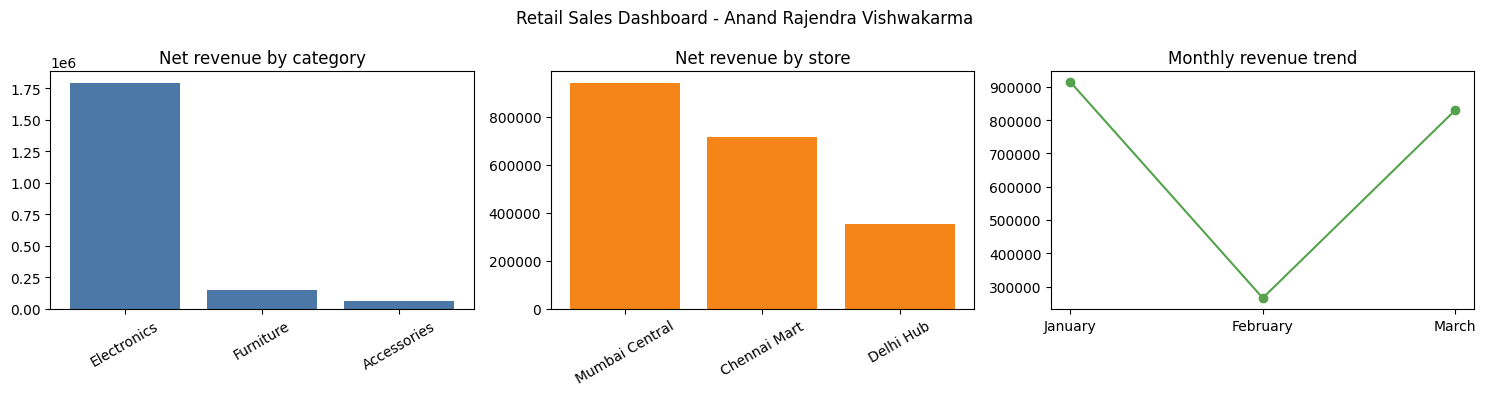

Chart saved as sales_dashboard.png

Submitted by: Anand Rajendra Vishwakarma


In [13]:
print_header("STAGE 6: SALES DASHBOARD (charts)")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(by_category["category"], by_category["net_revenue"], color="#4C78A8")
axes[0].set_title("Net revenue by category")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(by_store["store_name"], by_store["net_revenue"], color="#F58518")
axes[1].set_title("Net revenue by store")
axes[1].tick_params(axis="x", rotation=30)

axes[2].plot(monthly["month_name"], monthly["net_revenue"], marker="o", color="#54A24B")
axes[2].set_title("Monthly revenue trend")

plt.suptitle("Retail Sales Dashboard - " + STUDENT_NAME)
plt.tight_layout()
plt.savefig("sales_dashboard.png", dpi=120)
plt.show()
print("Chart saved as sales_dashboard.png")

print("\n" + "=" * 40)
print("Submitted by:", STUDENT_NAME)
print("=" * 40)